<a href="https://colab.research.google.com/github/imad2014/Analyse-du-Risque-de-Sinistre-Auto-Portefeuille-Marocain/blob/main/car_inssurence_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0. Imports et configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
from IPython.display import display
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
COLORS = {'primary': '#2E75B6', 'danger': '#C00000', 'success': '#1D9E75', 'warning': '#EF9F27'}

##  1. Chargement et Nettoyage des Données
### 1.1 Chargement

In [ ]:
data = pd.read_csv('/content/assurance_auto_raw.csv')

### 1.2 Rapport de qualité des données

In [ ]:
def rapport_data(df):
  info = pd.DataFrame({
      'type'   : df.dtypes,
      'Null'   : df.isna().sum(),
      '% Null' : (df.isnull().sum()/len(data))*100,
      'Uniques': df.nunique(),
  })
  return info
print ('              === RAPPORT QUALITE DONNES BRUT ===')
rapport = rapport_data(data)
print(rapport.to_string())
print('\n--- nnombre de colonnes Doublontes:{}'.format(data.duplicated().sum()))
print('--- IDs dupliqués : {}'.format(data['id_police'].duplicated().sum()))


              === RAPPORT QUALITE DONNES BRUT ===
                                   type  Null    % Null  Uniques
id_police                        object     0  0.000000     1000
age_conducteur                    int64     0  0.000000       62
genre                            object     0  0.000000        9
ville                            object     0  0.000000       13
categorie_socioprofessionnelle   object    47  4.630542        6
anciennete_permis_ans           float64    55  5.418719       52
marque_vehicule                  object     0  0.000000        8
age_vehicule_ans                float64    80  7.881773       23
puissance_fiscale_cv            float64    30  2.955665        9
usage_vehicule                   object     0  0.000000        3
km_annuels_estimes              float64    95  9.359606        9
formule_assurance                object     0  0.000000        6
coefficient_bonus_malus         float64    59  5.812808       91
nb_sinistres_anterieurs           int64 

### 1.3 Suppression des doublons

In [ ]:
# Supprimer les lignes entièrement dupliquées
data_F =  data.copy()
nbr_dup = data_F.duplicated().sum()
data_F.drop_duplicates(inplace=True)
print('doublons supprimés :{} \nlignes restantes : {}'.format(nbr_dup,len(data_F)))

doublons supprimés :10 
lignes restantes : 1005


In [ ]:
# Garder la première occurrence pour les IDs dupliqués
nbr_dup_id = data_F['id_police'].duplicated().sum()
data_F.drop_duplicates(subset=['id_police'],keep='first',inplace=True)
print ('IDs dupliqués supprimés:{}\nlignes restantes :{} '.format(nbr_dup_id,len(data_F)))


IDs dupliqués supprimés:5
lignes restantes :1000 


### 1.4 Correction des erreurs de saisie (standardisation)

In [ ]:
def unique_values_incategies_data(df):
  data_F_object_list = []
  for col in df.columns:
    if df[col].dtype == 'object':
      data_F_object_list.append(col)
  data_F_object_list.remove(data_F_object_list[0])
  data_F_object = data_F[data_F_object_list]
  for col in data_F_object.columns:
    print('{} : {}'.format(col,data_F_object[col].unique()))
unique_values_incategies_data(data_F)

genre : ['Homme' 'Femme' 'homme' 'Homme ' ' Homme' 'H' 'femme' 'FEMME' 'F']
ville : ['Marrakech' 'Oujda' 'Casablanca' 'Fes' 'Rabat' 'Tanger' ' Tanger'
 'Meknes' 'Agadir' 'marrakech' 'fes ' 'RABAT' 'Fès']
categorie_socioprofessionnelle : ['Commercant' 'Employe' 'Cadre' 'Independant' 'Etudiant' 'Retraite' nan]
marque_vehicule : ['Renault' 'Peugeot' 'Dacia' 'Volkswagen' 'Toyota' 'Hyundai' 'Fiat' 'Ford']
usage_vehicule : ['Personnel' 'Domicile_Travail' 'Professionnel']
formule_assurance : ['Tiers_Etendu' 'Tous_Risques' 'RC' 'rc' 'tous risques' 'tiers etendu']


In [ ]:
# --- Genre ---

data_F['genre'] = data_F['genre'].str.strip().str.capitalize()
data_F['genre'] = data_F['genre'].replace({'H':'Homme','F':'Femme'})

data_F.loc[data_F['genre'].str.startswith('H',na = False),'genre'] = 'Homme'
data_F.loc[data_F['genre'].str.startswith('F',na = False),'genre'] = 'Femme'
print('Valeurs genre après :', data_F['genre'].unique())

# --- Ville ---

data_F['ville'] = data_F['ville'].str.strip().str.capitalize()
data_F['ville'] = data_F['ville'].replace({'Fès':'Fes'})
print('Valeurs Ville après :',sorted(data_F['ville'].unique()))

# --- Formule ---
data_F['formule_assurance'] = data_F['formule_assurance'].str.strip().str.upper()
data_F['formule_assurance'] = data_F['formule_assurance'].replace({
      'TIERS ETENDU':'TIERS_ETENDU',
      'TOUS RISQUES':'TOUS_RISQUES',
      'RC' : 'RC'
})
print('Valeurs Formule après :',sorted(data_F['formule_assurance'].unique()))

Valeurs genre après : ['Homme' 'Femme']
Valeurs Ville après : ['Agadir', 'Casablanca', 'Fes', 'Marrakech', 'Meknes', 'Oujda', 'Rabat', 'Tanger']
Valeurs Formule après : ['RC', 'TIERS_ETENDU', 'TOUS_RISQUES']


### 1.5 Traitement des valeurs aberrantes

In [ ]:
def numerical_data(df):
  data_F_numerical_list=[]
  for col in df.columns:
    if df[col].dtype != 'object':
      data_F_numerical_list.append(col)
  data_F_numerical = data_F[data_F_numerical_list]
  return data_F_numerical

In [ ]:
data_F[data_F['montant_sinistre_mad']== 9999999.0]


,id_police,age_conducteur,genre,ville,categorie_socioprofessionnelle,anciennete_permis_ans,marque_vehicule,age_vehicule_ans,puissance_fiscale_cv,usage_vehicule,km_annuels_estimes,formule_assurance,coefficient_bonus_malus,nb_sinistres_anterieurs,prime_annuelle_ttc_mad,sinistre_declare,montant_sinistre_mad
10,POL-00011,28,Homme,Tanger,Commercant,6.0,Renault,14.0,8.0,Domicile_Travail,15000.0,TOUS_RISQUES,0.90,0,1334.55,1,9999999.0
16,POL-00017,41,Homme,Casablanca,Employe,20.0,Renault,13.0,7.0,Personnel,30000.0,RC,0.87,2,865.15,1,9999999.0
40,POL-00041,61,Homme,Marrakech,Employe,43.0,Volkswagen,17.0,9.0,Domicile_Travail,20000.0,TIERS_ETENDU,1.08,0,1292.58,1,9999999.0
47,POL-00048,24,Homme,Rabat,Employe,2.0,Peugeot,14.0,9.0,Personnel,15000.0,TOUS_RISQUES,0.67,0,1330.84,1,9999999.0
59,POL-00060,19,Homme,Agadir,Cadre,1.0,Fiat,8.0,6.0,Personnel,20000.0,RC,0.66,2,804.81,1,9999999.0


In [ ]:
# Age conducteur : valeurs valides entre 18 et 100 ans

mask_age = ~data_F['age_conducteur'].between(18,100)
print(f'🔴 Ages aberrants : {mask_age.sum()} → remplacés par NaN')
data_F.loc[mask_age, 'age_conducteur'] = np.nan

# Age véhicule : entre 0 et 40 ans-

mask_age_vehicule_ans = ~data_F['age_vehicule_ans'].between(0,40) & data_F['age_vehicule_ans'].notna()
print(f'🔴 Age vehicule aberrants : {mask_age_vehicule_ans.sum()} → remplacés par NaN')
data_F.loc[mask_age_vehicule_ans, 'age_vehicule_ans'] = np.nan

# km_annuels : entre 1 000 et 200 000 km
mask_km_annuels_estimes = ~data_F['km_annuels_estimes'].between(1000,200000) & data_F['km_annuels_estimes'].notna()
print(f'🔴 km annuels aberrants : {mask_km_annuels_estimes.sum()} → remplacés par NaN')
data_F.loc[mask_km_annuels_estimes, 'km_annuels_estimes'] = np.nan

# Bonus-malus : entre 0.50 et 3.50

mask_coefficient_bonus_malus = data_F['coefficient_bonus_malus'].notna() & ~data_F['coefficient_bonus_malus'].between(0.50,3.50)
print(f'🔴 Coefficient bonus_malus aberrants : {mask_coefficient_bonus_malus.sum()} → remplacés par NaN')
data_F.loc[mask_coefficient_bonus_malus,'coefficient_bonus_malus'] = np.nan

# Prime : entre 465 et 1648 MAD
Q1 = data_F['prime_annuelle_ttc_mad'].quantile(0.25)
Q3 = data_F['prime_annuelle_ttc_mad'].quantile(0.75)
IQR = Q3 - Q1
inervalle_iqr = [int(Q1-1.5*IQR),int(Q3+1.5*IQR)]
print("l'intervalle estimer pour le prime annuelle par la methode iterquartille est : {}".format(inervalle_iqr))
mask_prime_annuelle_tt = data_F['prime_annuelle_ttc_mad'].notna() & ~data_F['prime_annuelle_ttc_mad'].between(int(Q1-1.5*IQR),int(Q3+1.5*IQR))
print(f'🔴 Prime annuelle aberrants : {mask_prime_annuelle_tt.sum()} → remplacés par NaN')
data_F.loc[mask_prime_annuelle_tt,'prime_annuelle_ttc_mad'] = np.nan

#Un sinistre auto au Maroc dépasse rarement 300 000 MAD
mantant_reel = data_F[data_F['sinistre_declare']==1]['montant_sinistre_mad']
#q1 = mantant_reel.quantile(0.25)
#print(q1)
#q3 = mantant_reel.quantile(0.75)
#print(q3)
#iqr = q3 - q1
#inervalle_iqrm_coef_3 = [max(0,int(q1-3*iqr)),int(q3+3*iqr)]
#print("l'intervalle estimer pour le montant sinistre par la methode iterquartille est : {}".format(inervalle_iqrm_coef_3))

#mask_montant_sinistre_mad = data_F['montant_sinistre_mad'].notna() & ~data_F['montant_sinistre_mad'].between(int(q1-3*iqr),int(q3+3*iqr))
#data_F.loc[mask_montant_sinistre_mad,'montant_sinistre_mad'] = np.nan



print('\n=== APRÈS NETTOYAGE OUTLIERS ===')
print(data_F[["age_conducteur","prime_annuelle_ttc_mad","coefficient_bonus_malus","km_annuels_estimes","montant_sinistre_mad"]].describe().round(1))



🔴 Ages aberrants : 8 → remplacés par NaN
🔴 Age vehicule aberrants : 5 → remplacés par NaN
🔴 km annuels aberrants : 7 → remplacés par NaN
🔴 Coefficient bonus_malus aberrants : 10 → remplacés par NaN
l'intervalle estimer pour le prime annuelle par la methode iterquartille est : [465, 1648]
🔴 Prime annuelle aberrants : 6 → remplacés par NaN

=== APRÈS NETTOYAGE OUTLIERS ===
       age_conducteur  prime_annuelle_ttc_mad  coefficient_bonus_malus  \
count           992.0                   994.0                    931.0   
mean             46.1                  1066.7                      0.9   
std              16.3                   191.9                      0.2   
min              18.0                   800.0                      0.5   
25%              33.0                   911.5                      0.7   
50%              46.0                  1050.3                      0.9   
75%              60.0                  1204.8                      1.0   
max              74.0             

In [ ]:
#Un sinistre auto au Maroc dépasse rarement 300 000 MAD

mask_prime_sinistre_pour_valeur_abberantes= (data_F['sinistre_declare'] == 1) & (data_F['montant_sinistre_mad']>21648.85)
display(data_F[mask_prime_sinistre_pour_valeur_abberantes])

# remplir les valeurs aberrantes de 9999999.00  par un plafonnement à 30 000 MAD , Cela préserve le fait que ces lignes étaient des sinistres importants.

data_F.loc[mask_prime_sinistre_pour_valeur_abberantes,'montant_sinistre_mad'] = 30000
display(data_F[mask_prime_sinistre_pour_valeur_abberantes])



,id_police,age_conducteur,genre,ville,categorie_socioprofessionnelle,anciennete_permis_ans,marque_vehicule,age_vehicule_ans,puissance_fiscale_cv,usage_vehicule,km_annuels_estimes,formule_assurance,coefficient_bonus_malus,nb_sinistres_anterieurs,prime_annuelle_ttc_mad,sinistre_declare,montant_sinistre_mad
10,POL-00011,28.0,Homme,Tanger,Commercant,6.0,Renault,14.0,8.0,Domicile_Travail,15000.0,TOUS_RISQUES,0.90,0,1334.55,1,9999999.0
16,POL-00017,41.0,Homme,Casablanca,Employe,20.0,Renault,13.0,7.0,Personnel,30000.0,RC,0.87,2,865.15,1,9999999.0
40,POL-00041,61.0,Homme,Marrakech,Employe,43.0,Volkswagen,17.0,9.0,Domicile_Travail,20000.0,TIERS_ETENDU,1.08,0,1292.58,1,9999999.0
47,POL-00048,24.0,Homme,Rabat,Employe,2.0,Peugeot,14.0,9.0,Personnel,15000.0,TOUS_RISQUES,0.67,0,1330.84,1,9999999.0
59,POL-00060,19.0,Homme,Agadir,Cadre,1.0,Fiat,8.0,6.0,Personnel,20000.0,RC,0.66,2,804.81,1,9999999.0


,id_police,age_conducteur,genre,ville,categorie_socioprofessionnelle,anciennete_permis_ans,marque_vehicule,age_vehicule_ans,puissance_fiscale_cv,usage_vehicule,km_annuels_estimes,formule_assurance,coefficient_bonus_malus,nb_sinistres_anterieurs,prime_annuelle_ttc_mad,sinistre_declare,montant_sinistre_mad
10,POL-00011,28.0,Homme,Tanger,Commercant,6.0,Renault,14.0,8.0,Domicile_Travail,15000.0,TOUS_RISQUES,0.90,0,1334.55,1,30000.0
16,POL-00017,41.0,Homme,Casablanca,Employe,20.0,Renault,13.0,7.0,Personnel,30000.0,RC,0.87,2,865.15,1,30000.0
40,POL-00041,61.0,Homme,Marrakech,Employe,43.0,Volkswagen,17.0,9.0,Domicile_Travail,20000.0,TIERS_ETENDU,1.08,0,1292.58,1,30000.0
47,POL-00048,24.0,Homme,Rabat,Employe,2.0,Peugeot,14.0,9.0,Personnel,15000.0,TOUS_RISQUES,0.67,0,1330.84,1,30000.0
59,POL-00060,19.0,Homme,Agadir,Cadre,1.0,Fiat,8.0,6.0,Personnel,20000.0,RC,0.66,2,804.81,1,30000.0


### 1.6 Correction des incohérences logiques

In [ ]:
# Sinistre=0 mais montant > 0 → incohérence : remettre montant à 0

mask_inc_1 = (data_F['sinistre_declare'] == 0) & (data_F['montant_sinistre_mad'] > 0)
print(f'🔴 Incohérence sinistre=0 & montant>0 : {mask_inc_1.sum()} lignes → montant remis à 0')
data_F.loc[mask_inc_1,'montant_sinistre_mad'] = 0

# Sinistre=1 mais montant = 0 → montant inconnu → NaN

mask_inc_2 = (data_F['sinistre_declare'] == 1) & (data_F['montant_sinistre_mad'] <= 0)
print(f'🔴 Incohérence sinistre=1 & montant=0 : {mask_inc_2.sum()} lignes → montant mis à NaN')
data_F.loc[mask_inc_2,'montant_sinistre_mad'] = np.nan

🔴 Incohérence sinistre=0 & montant>0 : 12 lignes → montant remis à 0
🔴 Incohérence sinistre=1 & montant=0 : 1 lignes → montant mis à NaN


### 1.7 Imputation des valeurs manquantes

In [ ]:
# Variables numériques → médiane (robuste aux outliers)
num_cols =[]
for col in data_F[numerical_data(data_F).columns]:
  if data_F[col].isna().sum() >0:
    num_cols .append(col)
for c in num_cols:
  n_nan = data_F[c].isnull().sum()
  mediane = data_F[c].median()
  data_F[c] = data_F[c].fillna(mediane)
  print(f'✅ {c:35s} → {n_nan} NaN imputés par médiane ({mediane:.2f})')

# Variables catégorielles → mode (valeur la plus fréquente) | normalement faire sans boucle for
cat_cols = ['categorie_socioprofessionnelle']
for col in cat_cols:
    n_nan1 = data_F[col].isnull().sum()
    if n_nan1 > 0:
        mode = data_F[col].mode()[0]
        data_F[col] = data_F[col].fillna(mode)
        print(f'✅ {col:35s} → {n_nan1} NaN imputés par mode ("{mode}")')

print(f'\n🟢 NaN restants : {data_F.isnull().sum().sum()}')
print(f'🟢 Dataset propre : {data_F.shape}')

✅ age_conducteur                      → 8 NaN imputés par médiane (46.00)
✅ anciennete_permis_ans               → 54 NaN imputés par médiane (27.00)
✅ age_vehicule_ans                    → 85 NaN imputés par médiane (10.00)
✅ puissance_fiscale_cv                → 30 NaN imputés par médiane (7.00)
✅ km_annuels_estimes                  → 101 NaN imputés par médiane (15000.00)
✅ coefficient_bonus_malus             → 69 NaN imputés par médiane (0.86)
✅ prime_annuelle_ttc_mad              → 6 NaN imputés par médiane (1050.34)
✅ montant_sinistre_mad                → 1 NaN imputés par médiane (0.00)
✅ categorie_socioprofessionnelle      → 45 NaN imputés par mode ("Employe")

🟢 NaN restants : 0
🟢 Dataset propre : (1000, 17)


In [ ]:
data_F.describe().round(1)

,age_conducteur,anciennete_permis_ans,age_vehicule_ans,puissance_fiscale_cv,km_annuels_estimes,coefficient_bonus_malus,nb_sinistres_anterieurs,prime_annuelle_ttc_mad,sinistre_declare,montant_sinistre_mad
count,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
mean,46.1,26.4,9.7,7.3,17545.0,0.9,0.6,1066.6,0.1,472.0
std,16.2,15.4,5.5,1.8,7490.3,0.2,0.9,191.3,0.3,2502.0
min,18.0,0.0,0.0,4.0,5000.0,0.5,0.0,800.0,0.0,0.0
25%,33.0,14.0,5.0,6.0,15000.0,0.7,0.0,912.2,0.0,0.0
50%,46.0,27.0,10.0,7.0,15000.0,0.9,0.0,1050.3,0.0,0.0
75%,59.2,40.0,14.0,8.0,20000.0,1.0,1.0,1204.0,0.0,0.0
max,74.0,52.0,19.0,12.0,40000.0,1.6,4.0,1642.6,1.0,30000.0


---
## 📊 2. Analyse Exploratoire (EDA)
### Question 1 : Quels profils présentent le plus grand risque de sinistre ?
### 2.1 Distribution de la variable cible

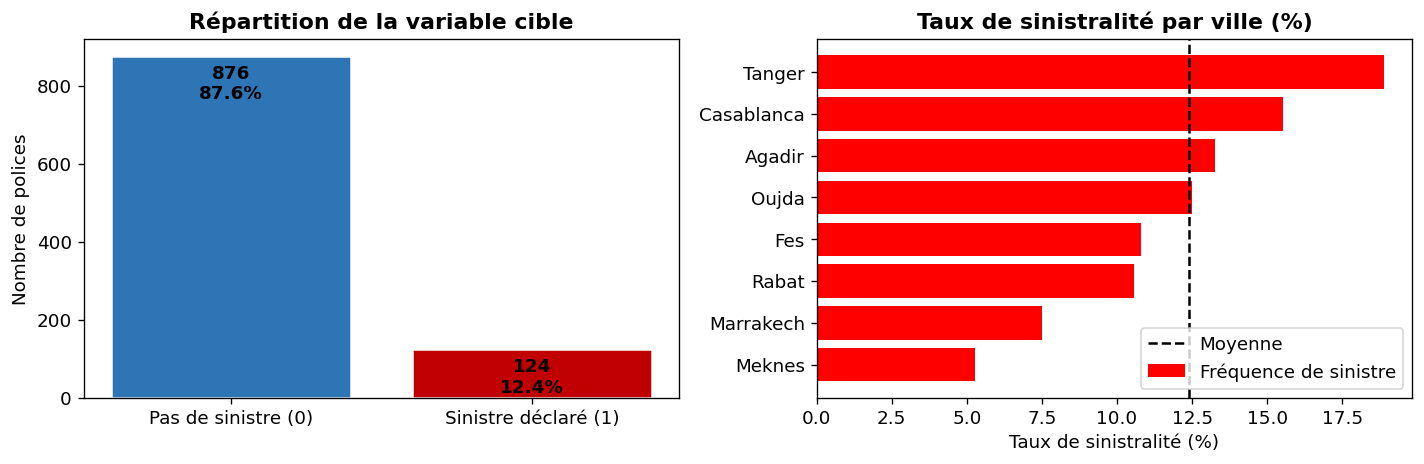

In [ ]:
# Répartition de la valeur cible
fig,axes = plt.subplots(1,2,figsize=(12,4))
counts = data_F['sinistre_declare'].value_counts()
axes[0].bar(['Pas de sinistre (0)', 'Sinistre déclaré (1)'],
            counts.values,
            color=[COLORS['primary'], COLORS['danger']],
            edgecolor='white', linewidth=1.5)
axes[0].set_title('Répartition de la variable cible', fontweight='bold')
axes[0].set_ylabel('Nombre de polices')
for i,v in enumerate(counts.values):
  axes[0].text(i , v-110,'{}\n{}%'.format(v,(v/len(data_F)*100)),ha='center',fontweight='bold')
# Taux de sinistralité par ville
sinistr_par_ville = data_F.groupby('ville')['sinistre_declare'].mean().sort_values(ascending=True)*100
axes[1].barh(sinistr_par_ville.index,sinistr_par_ville.values,linewidth=1.5,color = 'red',label = 'Fréquence de sinistre')
axes[1].axvline(data_F['sinistre_declare'].mean()*100, color='black', linestyle='--', label='Moyenne')
axes[1].set_title('Taux de sinistralité par ville (%)', fontweight='bold')
axes[1].set_xlabel('Taux de sinistralité (%)')
axes[1].legend()
plt.tight_layout()
plt.savefig('fig_01_target_distribution.png', bbox_inches='tight')
plt.show()

### 2.2 Taux de sinistralité par profil

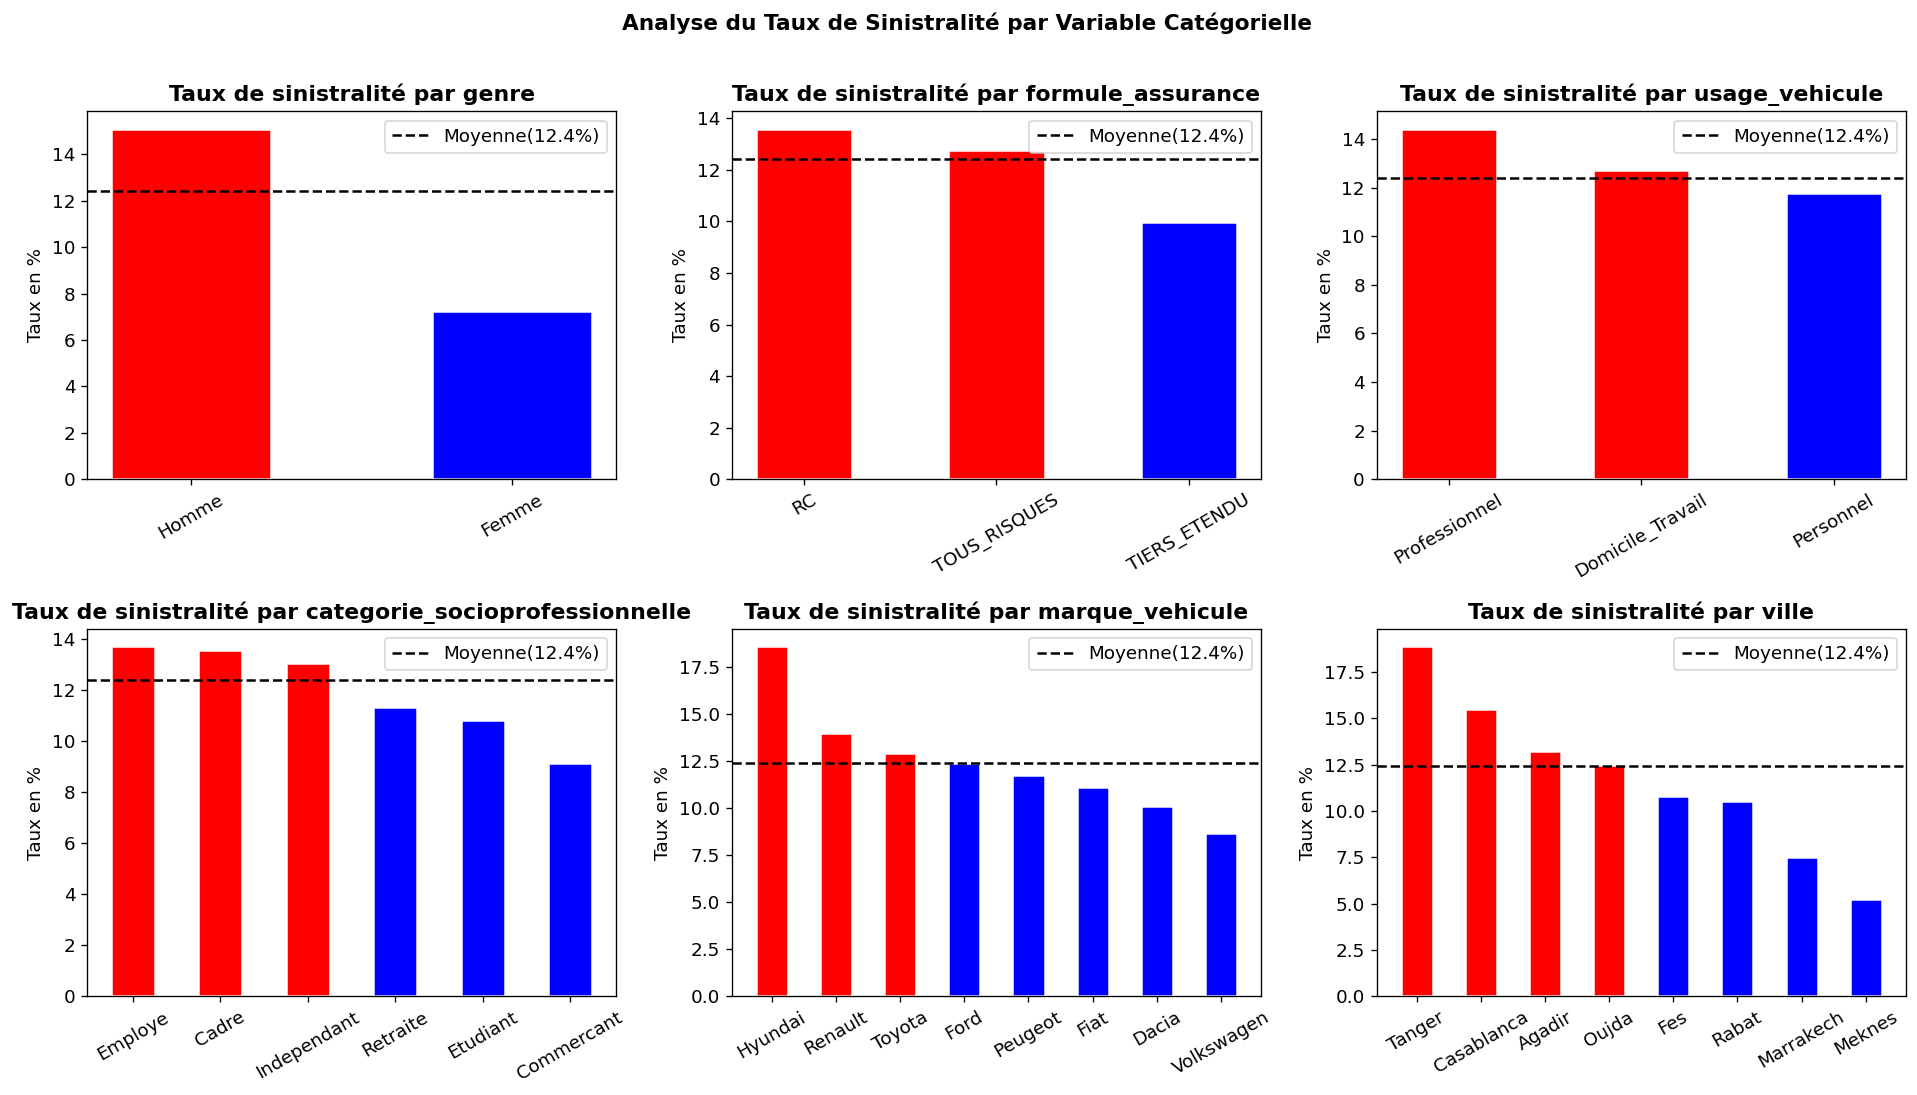

In [ ]:
fig,axes = plt.subplots(2,3,figsize=(16,9))
# Catégories à analyser
cat_vars = ['genre', 'formule_assurance', 'usage_vehicule',
            'categorie_socioprofessionnelle', 'marque_vehicule', 'ville']

for cat,ax in zip(cat_vars,axes.flatten()) :
  taux = data_F.groupby(cat)['sinistre_declare'].mean().sort_values(ascending=False)*100
  colorss = ['red' if v >= data_F['sinistre_declare'].mean()*100 else 'blue' for v in taux.values]
  ax.bar(taux.index,taux.values,color=colorss,edgecolor='white',linewidth=1.5,width=0.5)
  ax.axhline(data_F['sinistre_declare'].mean()*100,color='black',linestyle='--',label='Moyenne({}%)'.format(data_F['sinistre_declare'].mean()*100))
  ax.set_title('Taux de sinistralité par {}'.format(cat),fontweight='bold')
  ax.set_ylabel('Taux en %')
  ax.tick_params(axis='x', rotation=30)
  ax.legend()

plt.suptitle('Analyse du Taux de Sinistralité par Variable Catégorielle', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_02_sinistralite_categorielle.png', bbox_inches='tight')
plt.show()

### 2.3 Analyse des variables numériques vs sinistre

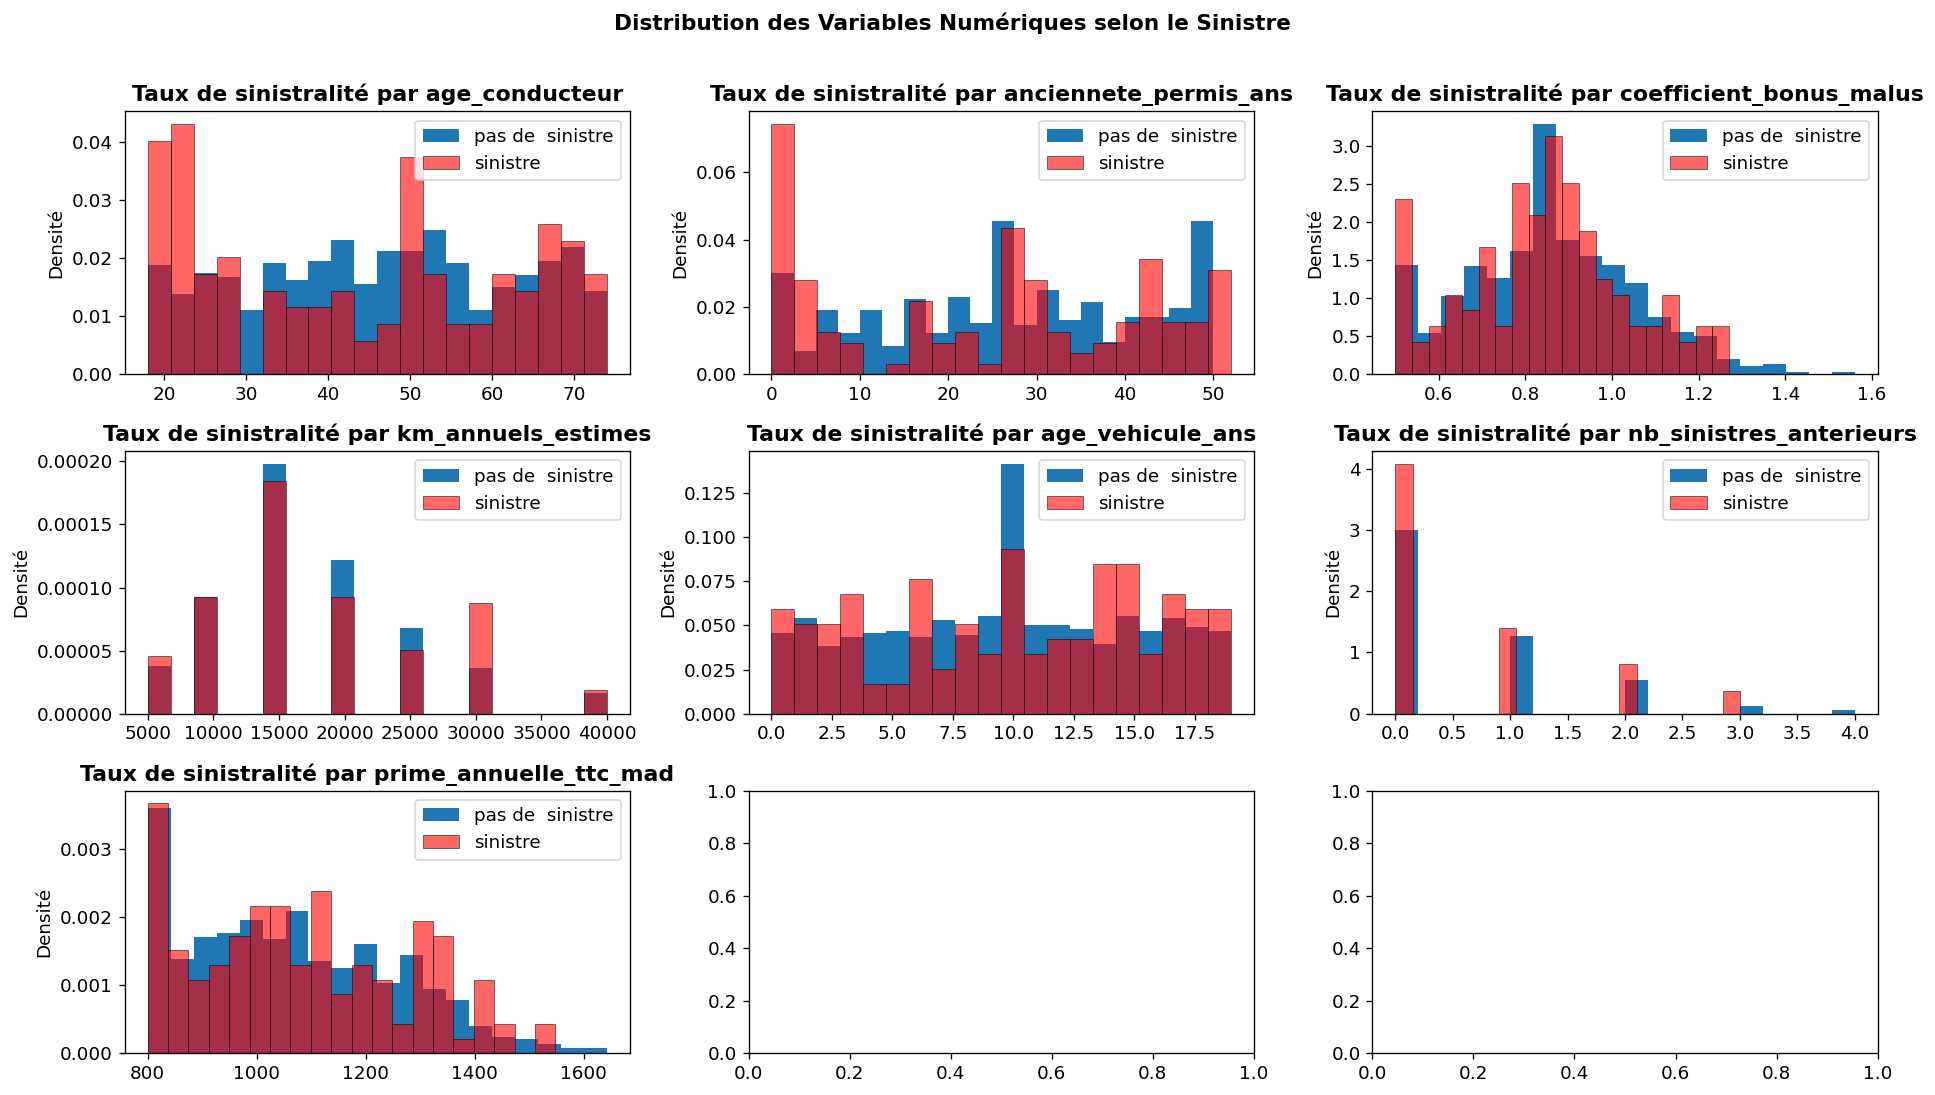

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(16, 9))
axes = axes.flatten()
# Catégories à analyser
num_vars = ['age_conducteur', 'anciennete_permis_ans', 'coefficient_bonus_malus',
            'km_annuels_estimes', 'age_vehicule_ans', 'nb_sinistres_anterieurs','prime_annuelle_ttc_mad']
for ax , var in zip(axes,num_vars):
  taux_sinistre0_var = data_F[data_F['sinistre_declare']==0][var].dropna()
  taux_sinistre1_var = data_F[data_F['sinistre_declare']==1][var].dropna()
  ax.hist(taux_sinistre0_var,bins = 20,density=True,label = 'pas de  sinistre')
  ax.hist(taux_sinistre1_var,bins = 20,density=True,alpha = 0.6,color = 'red',linewidth=0.5, edgecolor='black',label= 'sinistre')
  ax.set_title(f'Taux de sinistralité par {var}',fontweight='bold')
  ax.legend()
  ax.set_ylabel('Densité')

plt.suptitle('Distribution des Variables Numériques selon le Sinistre', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_03_distributions_numeriques.png', bbox_inches='tight')
plt.show()


### 2.4 Matrice de corrélation

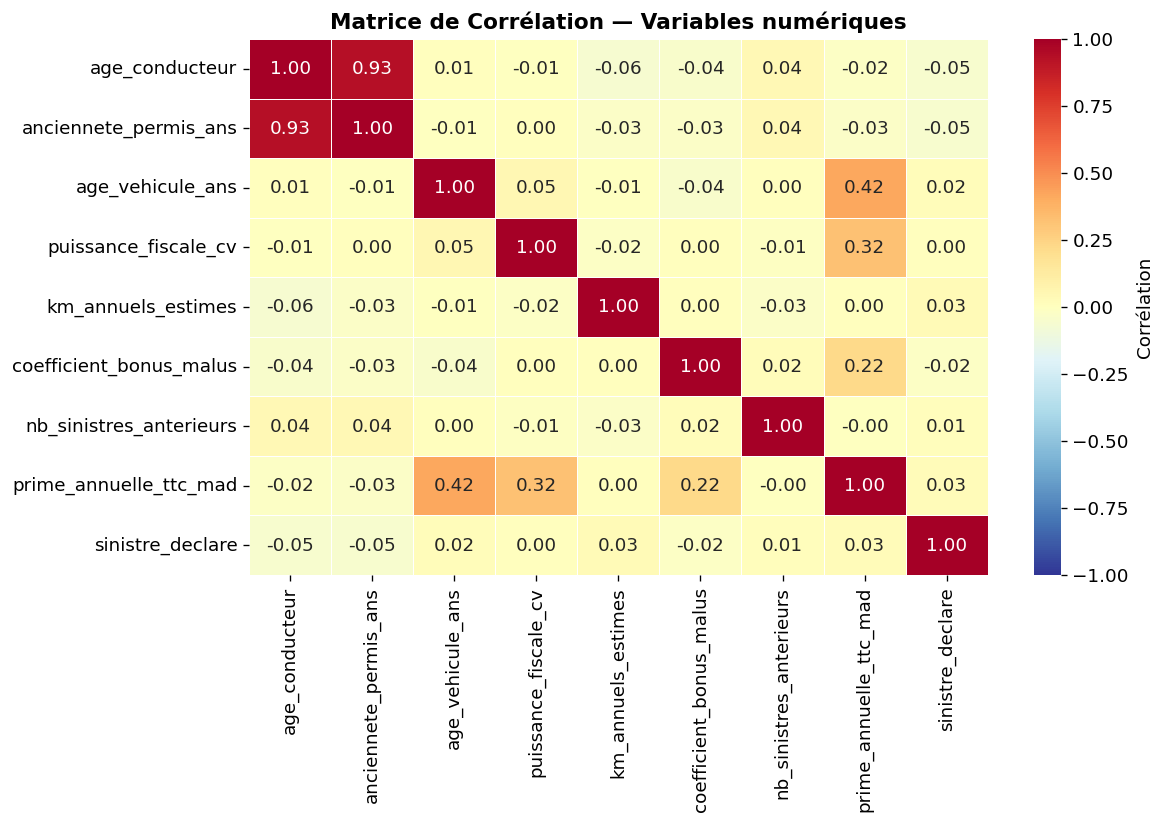

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
corr_vars = ['age_conducteur','anciennete_permis_ans','age_vehicule_ans','puissance_fiscale_cv',
             'km_annuels_estimes','coefficient_bonus_malus','nb_sinistres_anterieurs',
             'prime_annuelle_ttc_mad','sinistre_declare']
corr = data_F[corr_vars].corr()
#mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr,annot=True,fmt='.2f',cmap='RdYlBu_r',vmax=1,vmin=-1,center=0,cbar_kws={'label': 'Corrélation'},linewidths=0.5,ax=ax)
ax.set_title('Matrice de Corrélation — Variables numériques', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig_04_correlation_matrix.png', bbox_inches='tight')
plt.show()


---
## 💰 3. Analyse Actuarielle
### Question 2 : Les primes sont-elles cohérentes avec le risque réel ?

> **Principe actuariel** : La prime pure d'un assuré = Fréquence × Coût moyen du sinistre.
> Si la prime encaissée < prime pure → sous-tarification (perte pour l'assureur).

In [ ]:
#prime pure par segement :  genre, formule_assurance, usage_vehicule,categorie_socioprofessionnelle, marque_vehicule, ville
segments = ['genre', 'formule_assurance', 'usage_vehicule',
            'categorie_socioprofessionnelle', 'marque_vehicule', 'ville']
for segment in segments:
  frequence_sinistre  = data_F.groupby(segment)['sinistre_declare'].mean()
  cou_moyenne = data_F[data_F['sinistre_declare'] == 1].groupby(segment)['montant_sinistre_mad'].mean()
  prime_pure = frequence_sinistre * cou_moyenne
  prime_encaisser = data_F.groupby(segment)['prime_annuelle_ttc_mad'].mean()
  nb_police = data_F.groupby(segment)['id_police'].count()
  ecart_tarification = prime_encaisser - prime_pure
  # À ajouter après la création du DataFrame pour un effet "Wow"
  #display(info_tarifaction_par_usage.style.applymap(lambda x: 'color: red' if x == '🔴 Sous-tarifé' else 'color: green', subset=['statut']))
  info_tarifaction_par_segment = pd.DataFrame({
    'nb_polices': nb_police,
    'frequence_sinistre_%': (frequence_sinistre * 100),
    'cout_moyen': cou_moyenne,
    'prime_pure': prime_pure,
    'prime_encaissee': prime_encaisser,
    'ecart': ecart_tarification
    }).round(1)
  info_tarifaction_par_segment['statut'] = np.where(
    info_tarifaction_par_segment['ecart'] > 0,
    '✅ Sur-tarifé',
    '🔴 Sous-tarifé'
  )
  print('='*10+f' {segment.upper()} '+'='*10)
  display(info_tarifaction_par_segment)





========== GENRE ==========


,nb_polices,frequence_sinistre_%,cout_moyen,prime_pure,prime_encaissee,ecart,statut
genre,,,,,,,
Femme,344,7.3,2301.8,167.3,1061.6,894.3,✅ Sur-tarifé
Homme,656,15.1,4186.1,631.7,1069.3,437.5,✅ Sur-tarifé


========== FORMULE_ASSURANCE ==========


,nb_polices,frequence_sinistre_%,cout_moyen,prime_pure,prime_encaissee,ecart,statut
formule_assurance,,,,,,,
RC,449,13.6,3303.2,448.8,948.0,499.2,✅ Sur-tarifé
TIERS_ETENDU,261,10.0,4100.8,408.5,1061.1,652.6,✅ Sur-tarifé
TOUS_RISQUES,290,12.8,4428.5,565.0,1255.3,690.3,✅ Sur-tarifé


========== USAGE_VEHICULE ==========


...

,nb_polices,frequence_sinistre_%,cout_moyen,prime_pure,prime_encaissee,ecart,statut
categorie_socioprofessionnelle,,,,,,,
Cadre,184,13.6,3052.8,414.8,1074.9,660.2,✅ Sur-tarifé
Commercant,164,9.1,4476.0,409.4,1078.3,668.9,✅ Sur-tarifé
Employe,313,13.7,4465.2,613.4,1066.9,453.5,✅ Sur-tarifé
Etudiant,83,10.8,2348.1,254.6,1061.2,806.6,✅ Sur-tarifé
Independant,168,13.1,3823.8,500.7,1048.5,547.8,✅ Sur-tarifé
Retraite,88,11.4,3125.1,355.1,1066.2,711.1,✅ Sur-tarifé


========== MARQUE_VEHICULE ==========


,nb_polices,frequence_sinistre_%,cout_moyen,prime_pure,prime_encaissee,ecart,statut
marque_vehicule,,,,,,,
Dacia,218,10.1,2620.6,264.5,1050.9,786.4,✅ Sur-tarifé
Fiat,54,11.1,8951.0,994.6,1087.5,92.9,✅ Sur-tarifé
Ford,89,12.4,2892.5,357.5,1053.7,696.2,✅ Sur-tarifé
Hyundai,113,18.6,1826.8,339.5,1090.0,750.5,✅ Sur-tarifé
Peugeot,170,11.8,4345.2,511.2,1044.6,533.4,✅ Sur-tarifé
Renault,179,14.0,4457.8,622.6,1078.2,455.6,✅ Sur-tarifé
Toyota,85,12.9,4034.7,522.1,1093.6,571.4,✅ Sur-tarifé
Volkswagen,92,8.7,5962.8,518.5,1068.8,550.3,✅ Sur-tarifé


========== VILLE ==========


,nb_polices,frequence_sinistre_%,cout_moyen,prime_pure,prime_encaissee,ecart,statut
ville,,,,,,,
Agadir,83,13.3,4744.8,628.8,1129.5,500.7,✅ Sur-tarifé
Casablanca,290,15.5,3735.4,579.6,1039.8,460.2,✅ Sur-tarifé
Fes,111,10.8,1582.1,171.0,1050.9,879.9,✅ Sur-tarifé
Marrakech,133,7.5,4720.2,354.9,1074.5,719.6,✅ Sur-tarifé
Meknes,57,5.3,1742.5,91.7,1051.4,959.7,✅ Sur-tarifé
Oujda,56,12.5,2619.4,327.4,1080.3,752.9,✅ Sur-tarifé
Rabat,180,10.6,4349.2,459.1,1087.9,628.8,✅ Sur-tarifé
Tanger,90,18.9,4664.8,881.1,1061.3,180.2,✅ Sur-tarifé


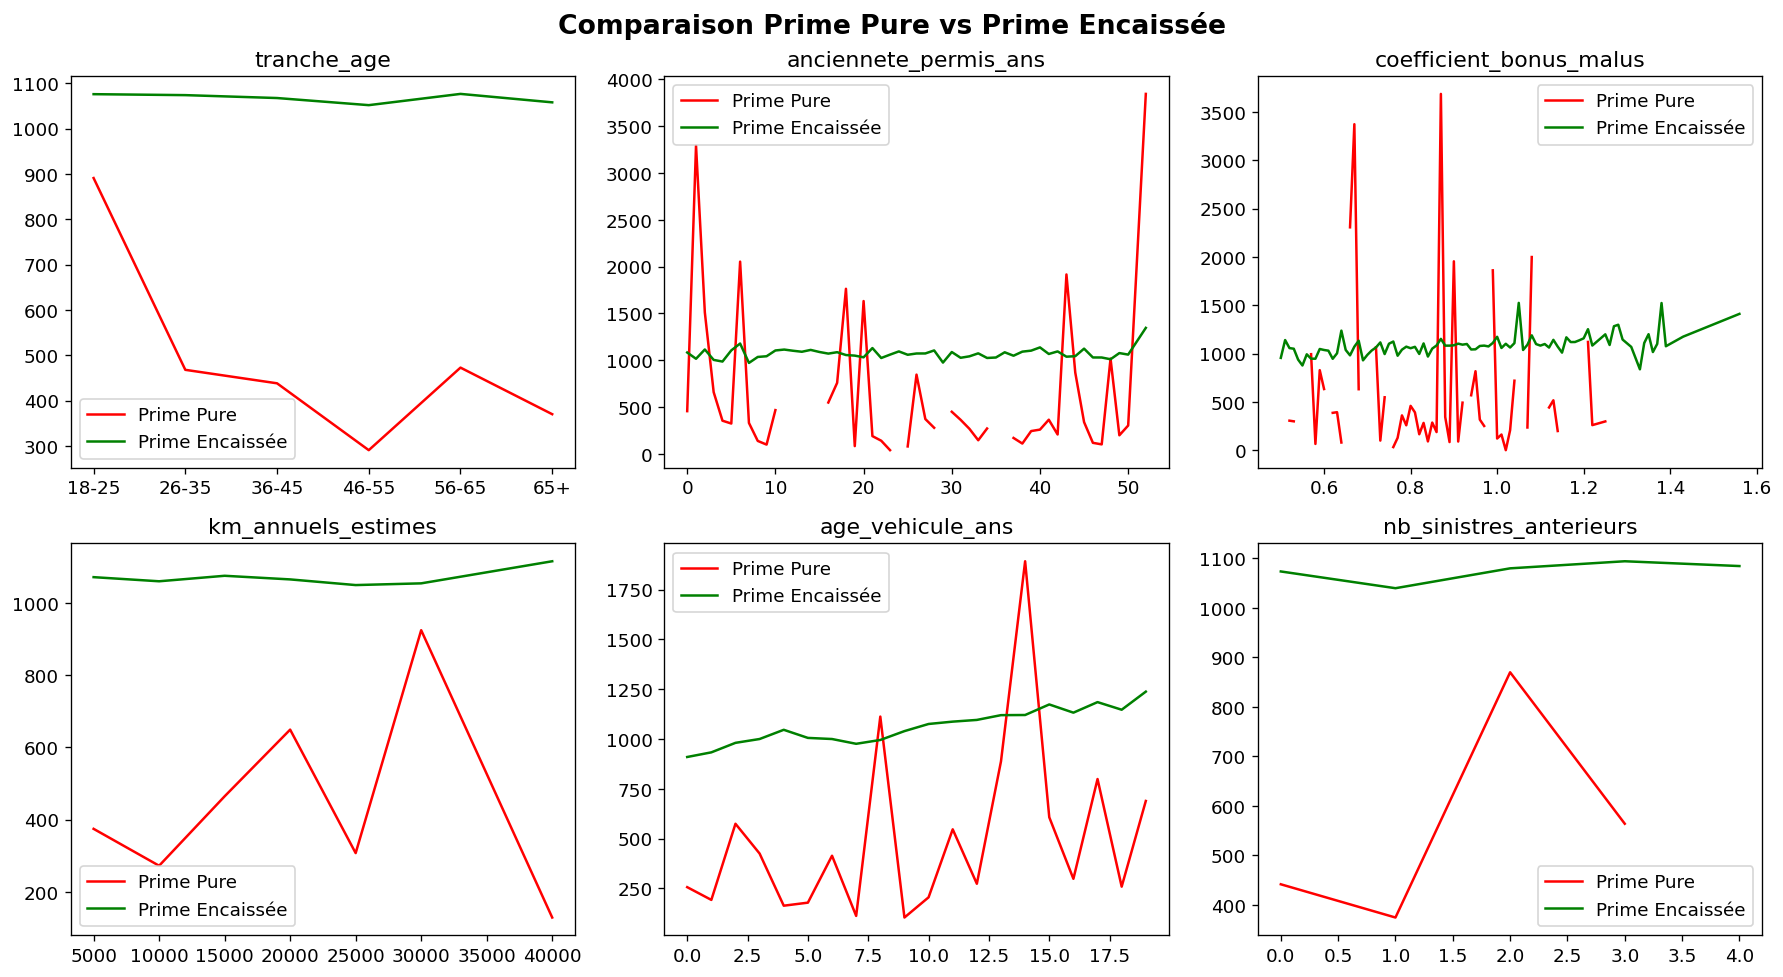

In [ ]:
seg_age = data_F.copy()
seg_age['tranche_age'] =pd.cut(data_F['age_conducteur'],bins = [17,25,35,45,55,65,100],labels = ['18-25','26-35','36-45','46-55','56-65','65+'])
frq_age = seg_age.groupby('tranche_age',observed=False)['sinistre_declare'].mean()
cou_moyenne_sinistre_age = seg_age[seg_age['sinistre_declare']==1].groupby('tranche_age',observed=False)['montant_sinistre_mad'].mean()
prime_pure_age = (frq_age * cou_moyenne_sinistre_age)
prime_encaisse_par_age = seg_age.groupby('tranche_age',observed=False)['prime_annuelle_ttc_mad'].mean()

# #prime pure vs prime encaissee par segement age_conducteur, anciennete_permis_ans, coefficient_bonus_malus, km_annuels_estimes, age_vehicule_ans, nb_sinistres_anterieurs,prime_annuelle_ttc_mad

fig ,axes = plt.subplots(3,3,figsize=(15,12))
axes = axes.flatten()
segments_num =['tranche_age','anciennete_permis_ans', 'coefficient_bonus_malus', 'km_annuels_estimes',
               'age_vehicule_ans', 'nb_sinistres_anterieurs']
for ax , var in zip(axes,segments_num):
  frq_seg = seg_age.groupby(var,observed=False)['sinistre_declare'].mean()
  cou_moyenne_sinistre_seg = seg_age[seg_age['sinistre_declare']==1].groupby(var,observed=True)['montant_sinistre_mad'].mean()
  prime_pure_seg = (frq_seg * cou_moyenne_sinistre_seg)
  prime_encaisse_par_seg = seg_age.groupby(var,observed=True)['prime_annuelle_ttc_mad'].mean()
  ax.plot(prime_pure_seg.index, prime_pure_seg.values, label='Prime Pure', color='red')
  ax.plot(prime_encaisse_par_seg.index, prime_encaisse_par_seg.values, label='Prime Encaissée', color='green')
  ax.set_title(var)
  ax.legend()
for i in range(len(segments_num), len(axes)):
    fig.delaxes(axes[i])
#x = np.arange(len(prime_pure_age))
#w = 0.4
#axes[0].set_xticks(x)
#axes[0].bar(x - w/2 ,prime_pure_age.values,w,color = 'red',label ='Prime pure (risque réel)')
#axes[0].bar(x + w/2 ,prime_encaisse_par_age.values,w,color = 'green',label ='Prime encaissée')
#axes[0].set_xticklabels(prime_pure_age.index)
#axes[0].set_title('Prime pure vs Prime encaissée\npar tranche d\'âge', fontweight='bold')
#axes[0].set_ylabel('MAD')
#axes[0].legend()
#frequence de sinistre par tranche
#freq_sinistre_par_tranche = seg_age.groupby('tranche_age',observed=False)['sinistre_declare'].mean()*100


#axes[1].bar(freq_sinistre_par_tranche.index,freq_sinistre_par_tranche.values,color = ['red' if v >= data_F['sinistre_declare'].mean()*100 else 'green' for v in freq_sinistre_par_tranche.values ])
#axes[1].axhline(seg_age['sinistre_declare'].mean()*100,color='black',linestyle='--',label='Moyenne')
#axes[1].set_title('Fréquence de sinistre\npar tranche d\'âge (%)', fontweight='bold')
#axes[1].set_ylabel('%')
#axes[1].legend()
fig.suptitle('Comparaison Prime Pure vs Prime Encaissée', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_05_analyse_actuarielle.png', bbox_inches='tight')
plt.show()

---
## 🤖 4. Modélisation Machine Learning
### Question 3 : Peut-on prédire si un assuré va déclarer un sinistre ?
### 4.1 Préparation des features